<a href="https://colab.research.google.com/github/VakeesanM/DL-Learning-Deliverables/blob/main/Week%204%20-%20InceptionNet/Deliverable_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.2 MB/s eta 0:00:00


In [124]:
import torch
import torch.nn as nn
import torchmetrics
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.models as models

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [10]:
train = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)
test = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 170M/170M [00:04<00:00, 40.7MB/s]


In [15]:
len(train), len(test)

(50000, 10000)

In [61]:
train_data_loader = DataLoader(train, batch_size=32, shuffle=True)
test_data_loader = DataLoader(test, 32, shuffle=True)

In [63]:
len(train_data_loader), len(test_data_loader)

(1563, 313)

In [22]:
image, l = train_data_loader.__iter__().__next__()
image.shape, l.shape

(torch.Size([64, 3, 32, 32]), torch.Size([64]))

In [47]:
def cal(in_channel):
  b1_out = int(in_channel / 3)

  b2_out_l1 = int(in_channel /2)
  b2_out_l2 = int(b2_out_l1 * (4/3))

  b3_out_l1 = int(in_channel /12)
  b3_out_l2 = int(b3_out_l1 * 2)

  b4_out = b3_out_l2

  return b1_out, b2_out_l2, b3_out_l2, b4_out
i = 96
sum(cal(i))/i

1.3333333333333333

In [135]:
class Inception_block(nn.Module):
  def __init__(self, in_channel=96,  input=True):
    super(Inception_block, self).__init__()
    # Calcuating Image Channels For Each Layer
    b1_out = int(in_channel / 3)

    b2_out_l1 = int(in_channel /2)
    b2_out_l2 = int(b2_out_l1 * (4/3))

    b3_out_l1 = int(in_channel /12)
    b3_out_l2 = b3_out_l1 * 2

    b4_out = b3_out_l2

    self.input = input

    self.Conv1 = nn.Conv2d(in_channels=3, out_channels=in_channel, kernel_size=(3, 3), stride=(1, 1))

    self.Block1 = nn.Sequential(
                    nn.Conv2d(in_channels=in_channel, out_channels=b1_out, kernel_size=(1, 1), stride=(1,1)),
                    nn.BatchNorm2d(b1_out),
                    nn.ReLU()
                    )

    self.Block2 = nn.Sequential(
                    nn.Conv2d(in_channels=in_channel, out_channels=b2_out_l1, kernel_size=(1, 1), stride=(1,1)),
                    nn.Conv2d(in_channels=b2_out_l1, out_channels=b2_out_l2, kernel_size=(3, 3), stride=(1,1), padding=(1, 1)),
                    nn.BatchNorm2d(b2_out_l2),
                    nn.ReLU()
                  )
    self.Block3 = nn.Sequential(
                    nn.Conv2d(in_channels=in_channel, out_channels=b3_out_l1, kernel_size=(1, 1), stride=(1,1)),
                    nn.Conv2d(in_channels=b3_out_l1, out_channels=b3_out_l2, kernel_size=(5, 5), stride=(1,1), padding=(2, 2)),
                    nn.BatchNorm2d(b3_out_l2),
                    nn.ReLU()
                )
    self.Block4 = nn.Sequential(
                    nn.MaxPool2d(kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
                    nn.Conv2d(in_channels=in_channel, out_channels=b4_out, kernel_size=(1, 1), stride=(1,1)),
                    nn.BatchNorm2d(b4_out),
                    nn.ReLU()
                )
  def forward(self, x):
    if self.input:
      x = self.Conv1(x)
    x1 = self.Block1(x)
    x2 = self.Block2(x)
    x3 = self.Block3(x)
    x4 = self.Block4(x)
    return torch.concat([x1, x2, x3, x4], dim=1)
class InceptionNet(nn.Module):
  def __init__(self, in_channel=96):
    super(InceptionNet, self).__init__()
    self.Layer1 = Inception_block(in_channel=in_channel)
    self.Layer2 = Inception_block(in_channel=int(in_channel*(4/3)), input=False)
    self.pool = nn.AdaptiveAvgPool2d((1, 1))

    self.fc = nn.Sequential(
      nn.Linear(in_features=167, out_features=334),
      nn.BatchNorm1d(334),
      nn.ReLU(),
      nn.Dropout(0.2),
      nn.Linear(in_features=334, out_features=10),
    )
  def forward(self, x):
    x = self.Layer1(x)
    x = self.Layer2(x)
    x = self.pool(x)
    x = torch.flatten(x, 1)

    x = self.fc(x)
    return x


In [136]:
model = InceptionNet(96).to(DEVICE)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()

In [137]:
train_losses = []
test_losses = []
accuracies = []
metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(DEVICE)

for epoch in range(10):
  train_loss = 0
  test_loss = 0
  accurracy = 0
  model.train()
  for image, label in train_data_loader:
    image = image.to(DEVICE)
    label = label.to(DEVICE)
    y_pred = model(image)
    loss = loss_fn(y_pred, label)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_losses.append(train_loss/len(train_data_loader))
  model.eval()
  for image, label in test_data_loader:
    image = image.to(DEVICE)
    label = label.to(DEVICE)
    y_pred = model(image)
    loss = loss_fn(y_pred, label)
    test_loss += loss.item()
    accurracy += metric(y_pred, label).item()
  accuracies.append(accurracy/len(test_data_loader))
  test_losses.append(test_loss/len(test_data_loader))
  print(f"Epoch: {epoch+1} | Train Loss: {train_losses[-1]} | Test Loss: {test_losses[-1]} | Accuracy: {accuracies[-1]*100:.3f}%")


Epoch: 1 | Train Loss: 1.5280849338340514 | Test Loss: 1.5026542127322846 | Accuracy: 46.226%
Epoch: 2 | Train Loss: 1.2302363203720488 | Test Loss: 1.2047406436917119 | Accuracy: 55.701%
Epoch: 3 | Train Loss: 1.1058312038237363 | Test Loss: 1.1364711856308836 | Accuracy: 57.907%
Epoch: 4 | Train Loss: 1.0294965884659584 | Test Loss: 1.2094547971368979 | Accuracy: 56.510%
Epoch: 5 | Train Loss: 0.9616439616306425 | Test Loss: 1.0553689993227633 | Accuracy: 62.440%
Epoch: 6 | Train Loss: 0.9209397041828146 | Test Loss: 1.0784465918144859 | Accuracy: 62.300%
Epoch: 7 | Train Loss: 0.8774822402557195 | Test Loss: 0.9376374063209985 | Accuracy: 66.034%
Epoch: 8 | Train Loss: 0.8418213949322472 | Test Loss: 0.9655211931600357 | Accuracy: 65.405%
Epoch: 9 | Train Loss: 0.8162131109301737 | Test Loss: 0.8335399682910297 | Accuracy: 70.188%
Epoch: 10 | Train Loss: 0.7870564535498543 | Test Loss: 0.877623266781481 | Accuracy: 68.431%


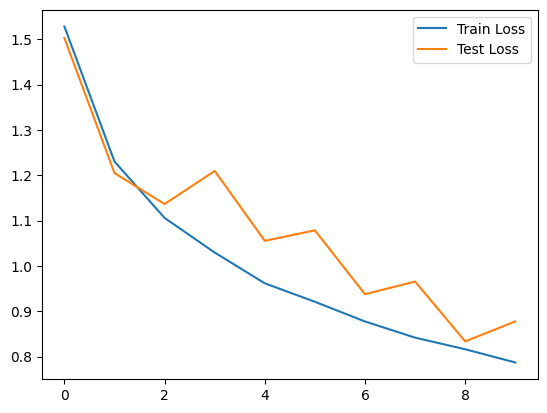

In [138]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Across Epoch")
plt.legend()
plt.show()

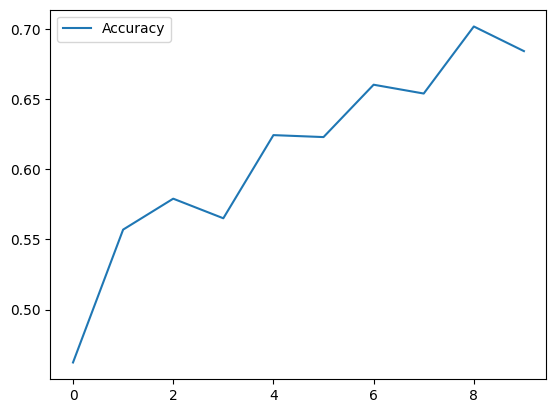

In [139]:
plt.plot(accuracies, label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuarcy Across Epoch")
plt.legend()
plt.show()